# Real data

## U.S. macroeconomic dataset

### Out of sample

In [1]:
import torch
import numpy as np
print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)

from argparse import Namespace
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.stats import t, norm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

from quantes.nonlinear import FNN, LocPoly
print(torch.cuda.is_available())
import math
from quantes.linear import joint
from utl import Qt_Linear
import pandas as pd
from arch.covariance.kernel import Andrews

PyTorch version: 2.6.0+cpu
NumPy version: 2.2.4
False


In [2]:
args = Namespace(
    tau=0.05,
    dof=2.25,
    scale_norm=1,
    scale_t=1/3,
    batch_size=32,
    val_pct=0,
    activation='relu',
    optimizer='adam',
    lr=0.01,
    max_epochs=50,
    patience=100,
    seed=2024,
    device = 'cpu'
)
params = {'batch_size' : args.batch_size, 
          'val_pct' : args.val_pct, 
          'width': 2,
          'depth' : 1,
          'activation' : args.activation, 
          'optimizer' : args.optimizer, 
          'lr' : args.lr,
          'n_epochs' : args.max_epochs,
          'early_stopping_patience' : args.patience}


### Load data

In [3]:
data = pd.read_excel('./realdata/DataVulnerability.xls', sheet_name='Data')
data.columns = ["Time", "GDP Growth", "NFCI"]
data.head()

,Time,GDP Growth,NFCI
0,1973-01-01,10.2,0.46
1,1973-04-01,4.6,0.91
2,1973-07-01,-2.2,1.67
3,1973-10-01,3.8,1.79
4,1974-01-01,-3.3,0.71


### Process data

In [4]:
data_all = data.copy()
data_all['Time'] = pd.to_datetime(data_all['Time'], format='%Y%m%d')
data_all.set_index('Time', inplace=True)
data_df = data_all['1973-01-01':'1992-10-01']
data_array = np.array(data_df)
total_n = data.shape[0]
init_n = data_df.shape[0]

### Model fitting with different $\tau$

In [5]:
args.tau = 0.05
fit_es_oop_5 = []
fit_es_oop_linear_5 = []
for index in range(total_n - init_n):
    Y = np.array(data_all['GDP Growth'])[1:init_n+index]
    n_oop = Y.shape[0]
    X_period = np.array(data_all[['NFCI','GDP Growth']])[:init_n+index]#.reshape(n,1)
    X = X_period[:n_oop]
    X_test = X_period[n_oop]
    exponent=.2
    torch.manual_seed(0)
    nn1 = FNN(X, Y)
    nn1.qt(tau=args.tau, options=params,plot=False)
    fit_q = nn1.predict(X)
    Z = np.minimum(Y - fit_q, 0) / args.tau
    huber_param = np.std(Z) * (n_oop/np.log(n_oop))**exponent
    
    torch.manual_seed(0)
    nn2 = FNN(X, Z + fit_q)
    nn2.ls(options=params, robust=True, c=huber_param, device = args.device,plot=False)
    
    
    fit_es_oop_5.append(nn2.predict(X_test.reshape(1, -1)))


In [6]:
args.tau = 0.025
fit_es_oop_25 = []
fit_es_oop_linear_25 = []
for index in range(total_n - init_n):
    Y = np.array(data_all['GDP Growth'])[1:init_n+index]
    n_oop = Y.shape[0]
    X_period = np.array(data_all[['NFCI','GDP Growth']])[:init_n+index]#.reshape(n,1)
    X = X_period[:n_oop]
    X_test = X_period[n_oop]
    exponent=.2
    torch.manual_seed(0)
    nn1 = FNN(X, Y)
    nn1.qt(tau=args.tau, options=params,plot=False)
    fit_q = nn1.predict(X)
    Z = np.minimum(Y - fit_q, 0) / args.tau
    huber_param = np.std(Z) * (n_oop/np.log(n_oop))**exponent
    
    torch.manual_seed(0)
    nn2 = FNN(X, Z + fit_q)
    nn2.ls(options=params, robust=True, c=huber_param, device = args.device, plot=False) 
    
    fit_es_oop_25.append(nn2.predict(X_test.reshape(1, -1)))

### Drawing results

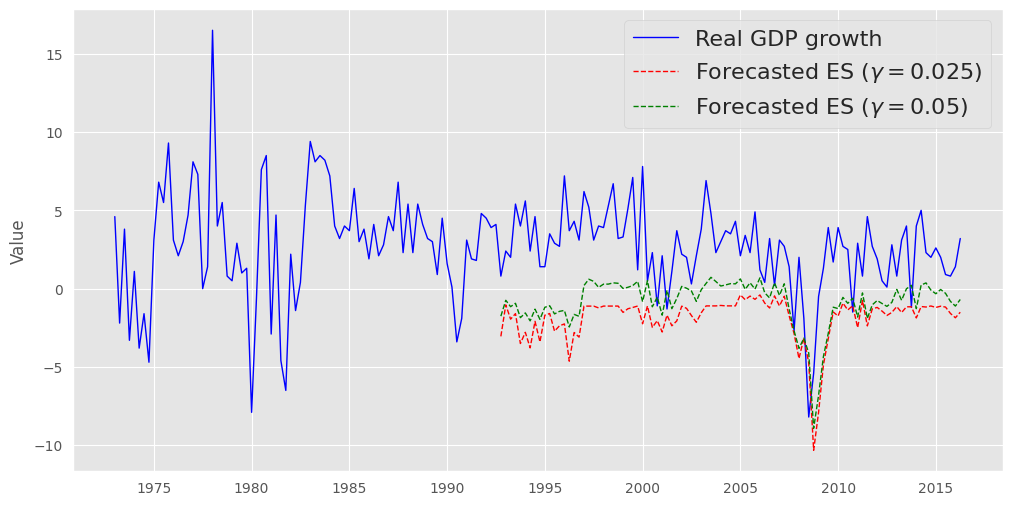

In [7]:
plt.figure(figsize=(12, 6)) 

Y_all = np.array(data['GDP Growth'])[1:]
n_y = Y_all.shape[0]


plt.plot(data['Time'][:n_y],Y_all, label='Real GDP growth', color='blue', linestyle='-', linewidth=1)
plt.plot(data['Time'][n_y - 95: n_y], fit_es_oop_25, 
         label=r'Forecasted ES ($\gamma = 0.025$)', 
         color='red', linestyle='--', linewidth=1)
plt.plot(data['Time'][n_y - 95: n_y], fit_es_oop_5, 
         label=r'Forecasted ES ($\gamma = 0.05$)', 
         color='green', linestyle='--', linewidth=1)
plt.legend(fontsize=16)
plt.ylabel('Value')
plt.savefig('./res_realdata/plot_estimate_es_nn_oop.pdf', bbox_inches='tight', format = "pdf")
plt.show()

## Fama-French

### Load data

In [8]:
five_ind_df = pd.read_csv("./realdata/5_Industry_Portfolios_Daily.csv",skiprows=9,skipfooter=1,engine='python')
five_factor_df = pd.read_csv("./realdata/F-F_Research_Data_5_Factors_2x3_daily.csv",skiprows=4, skipfooter=1,engine="python")

### Process data

In [9]:
five_ind_df.rename(columns={five_ind_df.columns[0]: 'Date'}, inplace=True)
five_factor_df.rename(columns={five_factor_df.columns[0]: 'Date'}, inplace=True)
five_ind_value_df = five_ind_df.iloc[:25901].copy()
five_ind_equal_df = five_ind_df.iloc[25903:].copy()

In [10]:
five_ind_value_df['Date'] = pd.to_datetime(five_ind_value_df['Date'], format='%Y%m%d')
five_ind_value_df.set_index('Date', inplace=True)
five_factor_df['Date'] = pd.to_datetime(five_factor_df['Date'], format='%Y%m%d')
five_factor_df.set_index('Date', inplace=True)
print(five_ind_value_df.head())
print(five_factor_df.head())

              Cnsmr    Manuf    HiTec     Hlth    Other
Date                                                   
1926-07-01    -0.09     0.22    -0.11     0.97     0.20
1926-07-02     0.46     0.69     0.31     0.13     0.10
1926-07-06     0.27     0.28     0.32     0.23    -0.18
1926-07-07    -0.01     0.11     0.12     0.33     0.16
1926-07-08     0.24     0.09     0.38     0.91     0.39
            Mkt-RF   SMB   HML   RMW   CMA    RF
Date                                            
1963-07-01   -0.67  0.00 -0.34 -0.01  0.16  0.01
1963-07-02    0.79 -0.26  0.26 -0.07 -0.20  0.01
1963-07-03    0.63 -0.17 -0.09  0.18 -0.34  0.01
1963-07-05    0.40  0.08 -0.27  0.09 -0.34  0.01
1963-07-08   -0.63  0.04 -0.18 -0.29  0.14  0.01


### Utility functions (including model fitting and plotting functions)

In [11]:
def fit_one_industry(
    X,
    Y,
    tau=0.1,
    val_ratio=0.3,
    grid_quantile=0.75,
    n_grid=10,
    ci_level=0.95,
    plot=False
):
    """
    Fit the LES-H estimator for one industry portfolio.

    Parameters
    ----------
    X : array-like, shape (n, d)
        Fama-French factors.
    Y : array-like, shape (n,)
        Industry portfolio return.
    tau : float
        Quantile/ES level.
    val_ratio : float
        Proportion of temporally ordered validation observations.
    grid_quantile : float
        Quantile used to construct the lower endpoint of the truncation grid.
    n_grid : int
        Number of candidate truncation thresholds.
    ci_level : float
        Confidence level.
    plot : bool
        Whether to plot the validation result in Qt_Linear.

    Returns
    -------
    result : dict
        Estimation results, confidence intervals, selected truncation
        threshold, and robustification parameter.
    """

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float).reshape(-1)

    n, d = X.shape

    # ---------------------------------------------------------
    # Step 1: construct candidate truncation thresholds
    # ---------------------------------------------------------
    abs_X = np.abs(X)
    coordinate_quantiles = np.quantile(
        abs_X,
        grid_quantile,
        axis=0
    )
    lower = np.max(coordinate_quantiles)
    upper = np.max(abs_X)

    vsigma = np.linspace(lower, upper, n_grid)

    # Temporally ordered training-validation split
    n_val = int(np.floor(val_ratio * n))
    split_point = n - n_val

    train_idx = np.arange(split_point)
    val_idx = np.arange(split_point, n)

    truncation_result = Qt_Linear(X[train_idx], Y[train_idx],
        X[val_idx], Y[val_idx], tau, vsigma,
        standardize=True, intercept=True,
        plot=plot
    )

    bvsigma = truncation_result["bvsigma_q"]

    # ---------------------------------------------------------
    # Step 2: truncate the factor observations
    # ---------------------------------------------------------
    X_truncated = np.clip(X, -bvsigma, bvsigma)

    # ---------------------------------------------------------
    # Step 3: preliminary smoothed quantile regression
    # ---------------------------------------------------------
    model = joint(X_truncated, Y)

    qr_residual = model.fit(tau=tau, kernel="Laplacian", standardize=True)["res"]

    # qr_residual = qrfit

    negative_residual = np.minimum(qr_residual, 0) / tau
    fourth_moment = np.mean(negative_residual**4)
    robust = (
        0.25
        * fourth_moment**0.25
        * (n / d / np.log(n)**2)**(1 / 6)
    )

    if not np.isfinite(robust) or robust <= 0:
        raise ValueError(
            f"The calculated robustification parameter is invalid: {robust}."
        )

    # ---------------------------------------------------------
    # Step 4: two-step LES-H estimator
    # ---------------------------------------------------------
    lesh_fit = model.twostep(
        tau=tau,
        loss="Huber",
        ci=True,
        standardize=True,
        robust=robust
    )

    coef_e = np.asarray(lesh_fit["coef_e"], dtype=float).reshape(-1)
    coef_q = np.asarray(lesh_fit["coef_q"], dtype=float).reshape(-1)

    # ---------------------------------------------------------
    # Step 5: long-run covariance estimation
    # ---------------------------------------------------------
    residual_e = np.asarray(lesh_fit["res_e"], dtype=float).reshape(-1)
    residual_e = np.clip(residual_e, -robust, robust)

    # Intercept followed by centered truncated predictors
    X_augmented = np.column_stack([np.ones(n), X_truncated])
    X_augmented[:, 1:] -= np.mean(X_augmented[:, 1:], axis=0)

    score_process = X_augmented * residual_e[:, None]
    long_run_cov = Andrews(score_process).cov.long_run
    design_cov = X_augmented.T @ X_augmented / n
    design_cov_inv = np.linalg.pinv(design_cov)

    asymptotic_cov = design_cov_inv@ long_run_cov@ design_cov_inv
    asymptotic_variance = np.diag(asymptotic_cov)

    alpha = 1 - ci_level
    critical_value = norm.ppf(1 - alpha / 2)

    ci_half_width = critical_value* np.sqrt(asymptotic_variance / n)/ tau

    ci_lower = coef_e - ci_half_width
    ci_upper = coef_e + ci_half_width

    return {
        "coef_e": coef_e,
        "coef_q": coef_q,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "standard_error": np.sqrt(asymptotic_variance / n) / tau,
        "asymptotic_cov": asymptotic_cov,
        "bvsigma": bvsigma,
        "robust": robust,
        "n": n,
        "fit": lesh_fit,
        "truncation_result": truncation_result
    }

def fit_all_industries(
    industry_df,  
    factor_df,   
    tau=0.1,     
    val_ratio=0.3,  
    grid_quantile=0.75,  
    n_grid=10,   
    ci_level=0.95,  
    plot=False,   
    verbose=True  
):
    """
    Fit LES-H for all five Fama-French industry portfolios.

    Returns
    -------
    numerical_df : pandas.DataFrame
        Long-format numerical results.
    formatted_df : pandas.DataFrame
        Results formatted as estimate (lower, upper).
    fitted_results : dict
        Complete fitted objects for every industry.
    """

    industry_df = industry_df.copy()
    factor_df = factor_df.copy()

    # Remove accidental whitespace, e.g. "Hlth "
    industry_df.columns = industry_df.columns.str.strip()
    factor_df.columns = factor_df.columns.str.strip()

    factor_columns = [
        "Mkt-RF",
        "SMB",
        "HML",
        "RMW",
        "CMA"
    ]

    industry_columns = [
        "Cnsmr",
        "Manuf",
        "HiTec",
        "Hlth",
        "Other"
    ]

    # Match observations by date rather than row position
    combined_df = industry_df[industry_columns].join(
        factor_df[factor_columns],
        how="inner"
    )

    combined_df = combined_df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    X = combined_df[factor_columns].to_numpy(dtype=float)

    # coef_e is assumed to be:
    # [Intercept, Mkt-RF, SMB, HML, RMW, CMA]
    internal_term_names = [
        "Intercept",
        "MKTRF",
        "SMB",
        "HML",
        "RMW",
        "CMA"
    ]

    # Desired order in the paper table
    table_term_names = [
        "MKTRF",
        "SMB",
        "HML",
        "RMW",
        "CMA",
        "Intercept"
    ]

    fitted_results = {}
    numerical_records = []
    formatted_records = {}

    for industry in industry_columns:

        if verbose:
            print("=" * 70)
            print(f"Fitting industry: {industry}")

        Y = combined_df[industry].to_numpy(dtype=float)

        fit_result = fit_one_industry(
            X=X,
            Y=Y,
            tau=tau,
            val_ratio=val_ratio,
            grid_quantile=grid_quantile,
            n_grid=n_grid,
            ci_level=ci_level,
            plot=plot
        )

        fitted_results[industry] = fit_result

        coef = fit_result["coef_e"]
        lower = fit_result["ci_lower"]
        upper = fit_result["ci_upper"]
        se = fit_result["standard_error"]

        result_by_term = {}

        for j, term in enumerate(internal_term_names):

            result_by_term[term] = {
                "estimate": coef[j],
                "lower": lower[j],
                "upper": upper[j],
                "se": se[j]
            }

            numerical_records.append(
                {
                    "Industry": industry,
                    "Term": term,
                    "Estimate": coef[j],
                    "Std. Error": se[j],
                    "CI Lower": lower[j],
                    "CI Upper": upper[j],
                    "Truncation": fit_result["bvsigma"],
                    "Robust": fit_result["robust"],
                    "Sample Size": fit_result["n"]
                }
            )

        formatted_records[industry] = {
            term: (
                f"{result_by_term[term]['estimate']:.3f} "
                f"({result_by_term[term]['lower']:.3f}, "
                f"{result_by_term[term]['upper']:.3f})"
            )
            for term in table_term_names
        }

    numerical_df = pd.DataFrame(numerical_records)

    formatted_df = pd.DataFrame.from_dict(
        formatted_records,
        orient="index"
    )

    formatted_df = formatted_df[table_term_names]
    formatted_df.index.name = "Industry"

    return numerical_df, formatted_df, fitted_results

In [12]:
industry_df = five_ind_value_df["1963-07-01":"2021-12-31"]
factor_df = five_factor_df["1963-07-01":"2021-12-31"]

### Model fitting

In [13]:
numerical_results, formatted_results, fitted_results = fit_all_industries(
    industry_df=industry_df,
    factor_df=factor_df,
    tau=0.1,
    val_ratio=0.3,
    grid_quantile=0.75,
    n_grid=10,
    ci_level=0.95,
    plot=False,
    verbose=True
)

Fitting industry: Cnsmr


Fitting industry: Manuf
Fitting industry: HiTec
Fitting industry: Hlth
Fitting industry: Other


In [14]:
formatted_results

,MKTRF,SMB,HML,RMW,CMA,Intercept
Industry,,,,,,
Cnsmr,"0.869 (0.799, 0.939)","0.090 (0.003, 0.176)","-0.139 (-0.253, -0.026)","0.516 (0.329, 0.702)","0.332 (0.147, 0.518)","-0.579 (-0.613, -0.544)"
Manuf,"1.001 (0.908, 1.094)","0.090 (0.008, 0.172)","0.030 (-0.191, 0.251)","0.506 (0.355, 0.658)","0.459 (0.216, 0.702)","-0.636 (-0.683, -0.589)"
HiTec,"1.014 (0.971, 1.056)","-0.091 (-0.171, -0.012)","-0.321 (-0.428, -0.215)","-0.616 (-0.796, -0.437)","-0.257 (-0.461, -0.052)","-0.711 (-0.742, -0.680)"
Hlth,"0.901 (0.823, 0.978)","0.030 (-0.107, 0.166)","-0.484 (-0.650, -0.318)","0.473 (0.165, 0.781)","0.658 (0.210, 1.106)","-1.012 (-1.070, -0.954)"
Other,"1.089 (1.026, 1.153)","0.131 (0.015, 0.246)","0.554 (0.436, 0.672)","0.048 (-0.109, 0.205)","-0.169 (-0.338, -0.000)","-0.563 (-0.597, -0.528)"


## Rolling-window estimates of the conditional 10\% ES coefficients for the five industry portfolios

### Utility functions (including model fitting and plotting functions)

In [15]:
def make_vsigma_grid(X_train, n_grid=10, q=0.75):
    absX = np.abs(X_train)
    lower = np.max(np.quantile(absX, q, axis=0))
    upper = np.max(absX)

    if not np.isfinite(lower) or not np.isfinite(upper):
        raise ValueError("lower or upper is not finite.")

    if upper <= lower:
        upper = lower + 1e-8

    return np.linspace(lower, upper, n_grid)


def fit_one_window_coef(Xw, Yw, tau=0.1, val_ratio=0.3, n_grid=10, loss = 'Huber'):
    """
    在一个 rolling window 内估计 quantile regression 参数。
    返回顺序：
        constant, mktrf, smb, hml, rmw, cma
    """

    Xw = np.asarray(Xw, dtype=float)
    Yw = np.asarray(Yw, dtype=float)

    mask = np.isfinite(Yw) & np.all(np.isfinite(Xw), axis=1)
    Xw = Xw[mask]
    Yw = Yw[mask]

    n, d = Xw.shape

    if n <= d + 30:
        return np.full(d + 1, np.nan)

    n_val = int(val_ratio * n)
    n_train = n - n_val

    X_train = Xw[:n_train]
    Y_train = Yw[:n_train]
    X_val = Xw[n_train:]
    Y_val = Yw[n_train:]

    vsigma = make_vsigma_grid(X_train, n_grid=n_grid, q=0.75)

    bvsigma_q = Qt_Linear(
        X_train, Y_train,
        X_val, Y_val,
        tau,
        vsigma,
        standardize=True,
        intercept=True,
        plot=False
    )['bvsigma_q']

    X_clip = np.clip(Xw, -bvsigma_q, bvsigma_q)

    lm = joint(X_clip, Yw)

    qrfit = lm.fit(
        tau=tau,
        kernel='Laplacian',
        standardize=True
    )

    robust = (
        0.25 * np.mean((np.minimum(qrfit['res'], 0) / tau) ** 4) ** 0.25
        * (n / d / (np.log(n) ** 2)) ** (1 / 6)
    )

    m4 = lm.twostep(
        tau=tau,
        loss=loss,
        ci=True,
        standardize=True,
        robust=robust
    )

    coef = np.asarray(m4['coef_e']).ravel()

    return coef

def rolling_coefficients(
    data,
    factor_cols,
    industry_cols,
    tau=0.1,
    window_years=20,
    first_start_year=1963,
    last_year=2021,
    n_grid=10,
    loss = 'Huber'
):
    coef_names = ['constant', 'mktrf', 'smb', 'hml', 'rmw', 'cma']

    industry_name_map = {
        'Cnsmr': 'Cnsmr',
        'Manuf': 'Manuf',
        'HiTec': 'Hitec',
        'Hlth': 'Hlth',
        'Other': 'Other'
    }

    first_end_year = first_start_year + window_years
    end_years = range(first_end_year, last_year + 1)

    out = {}
    years = data.index.year
    print(loss)

    for ind in industry_cols:
        rows = []

        for end_year in tqdm(end_years, desc=ind):
            # train_start = end_year - window_years
            train_start = end_year - window_years + 1
            train_end = end_year
            # print(train_start, train_end)

            train_mask = (years >= train_start) & (years <= train_end)
            sub = data.loc[train_mask]
            # print(sub)

            Xw = sub[factor_cols].to_numpy()
            Yw = sub[ind].to_numpy()

            try:
                coef = fit_one_window_coef(
                    Xw, Yw,
                    tau=tau,
                    val_ratio=0.3,
                    n_grid=n_grid,
                    loss = loss
                )
            except Exception as e:
                print(f"{ind}, end_year={end_year} failed: {e}")
                coef = np.full(len(coef_names), np.nan)

            rows.append(pd.Series(coef, index=coef_names, name=end_year))

        out[industry_name_map[ind]] = pd.DataFrame(rows)

    rolling_coefs = pd.concat(out, axis=1)
    rolling_coefs.index.name = 'year'

    return rolling_coefs

def plot_rolling_coefficients_together(rolling_coefs):

    # plt.style.use('default')
    sns.set_style("darkgrid")
    plt.rcParams.update({
        "font.size": 12,
        "font.weight": "semibold",
        "axes.labelsize": 12,
        "axes.labelweight": "semibold",
        "axes.titlesize": 13,
        "axes.titleweight": "semibold",
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9,
        "axes.linewidth": 1.1,
    })
   
    
    coef_order = ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'constant']
    ylims = [(0,2), (-1,1), (-3,2),(-3,2),(-2,4), (-3, 0.5)]

    title_map = {
        'mktrf': 'MKTRF Coefficients',
        'smb': 'SMB Coefficients',
        'hml': 'HML Coefficients',
        'rmw': 'RMW Coefficients',
        'cma': 'CMA Coefficients',
        'constant': 'Intercept Coefficients'
    }

    industry_order = ['Cnsmr', 'Manuf', 'Hitec', 'Hlth', 'Other']

    industry_label_map = {
        'Cnsmr': 'Cnsmr',
        'Manuf': 'Manuf',
        'Hitec': 'HiTec',
        'Hlth': 'Hlth',
        'Other': 'Other'
    }

    years = rolling_coefs.index.to_numpy()

    xmin = (years.min() // 10) * 10
    xmax = years.max()
    
    xticks = np.arange(xmin, xmax + 1, 10)

    fig, axes = plt.subplots(
        3, 2,
        figsize=(20, 18),
        sharex=False
    )

    axes = axes.ravel()

    
    

    # for ax, coef_name, ylim in zip(axes, coef_order, ylims):
    for ax, coef_name in zip(axes, coef_order):
        for ind in industry_order:
            ax.plot(
                rolling_coefs.index,
                rolling_coefs[(ind, coef_name)],
                marker='o',
                markersize=3,
                linewidth=2,
                label=industry_label_map[ind]
            )

        # ax.axhline(0, linewidth=0.8, alpha=0.5)
        ax.set_title(title_map[coef_name], loc='left', fontsize=18)
        # ax.set_xlabel('year')
        ax.set_ylabel('Coefficient')
        # ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # ax.set_ylim(ylim[0],ylim[1])

        ax.set_xticks(xticks)
        ax.tick_params(axis='x', labelbottom=True)
 

        ax.legend(
            loc='upper center',
            bbox_to_anchor=(0.5, 1.18),
            ncol=5,
            fontsize=15,
            frameon=False
        )

    plt.tight_layout()
    plt.savefig(f'./res_realdata/famafench_rolling.pdf', bbox_inches='tight', format="pdf")
    plt.show()

In [16]:
industry_df = industry_df.copy()
industry_df.columns = industry_df.columns.str.strip()

factor_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
industry_cols = ['Cnsmr', 'Manuf', 'HiTec', 'Hlth', 'Other']

data = factor_df[factor_cols].join(industry_df[industry_cols], how='inner')
data = data.loc['1963-07-01':'2021-12-31']
data = data.apply(pd.to_numeric, errors='coerce').dropna()

### Model fitting

In [17]:
rolling_coefs = rolling_coefficients(
    data=data,
    factor_cols=factor_cols,
    industry_cols=industry_cols,
    tau=0.1,
    window_years=20,
    first_start_year=1963,
    last_year=2021,
    n_grid=10
)

Huber


Cnsmr:   0%|          | 0/39 [00:00<?, ?it/s]

Manuf:   0%|          | 0/39 [00:00<?, ?it/s]

HiTec:   0%|          | 0/39 [00:00<?, ?it/s]

Hlth:   0%|          | 0/39 [00:00<?, ?it/s]

Other:   0%|          | 0/39 [00:00<?, ?it/s]

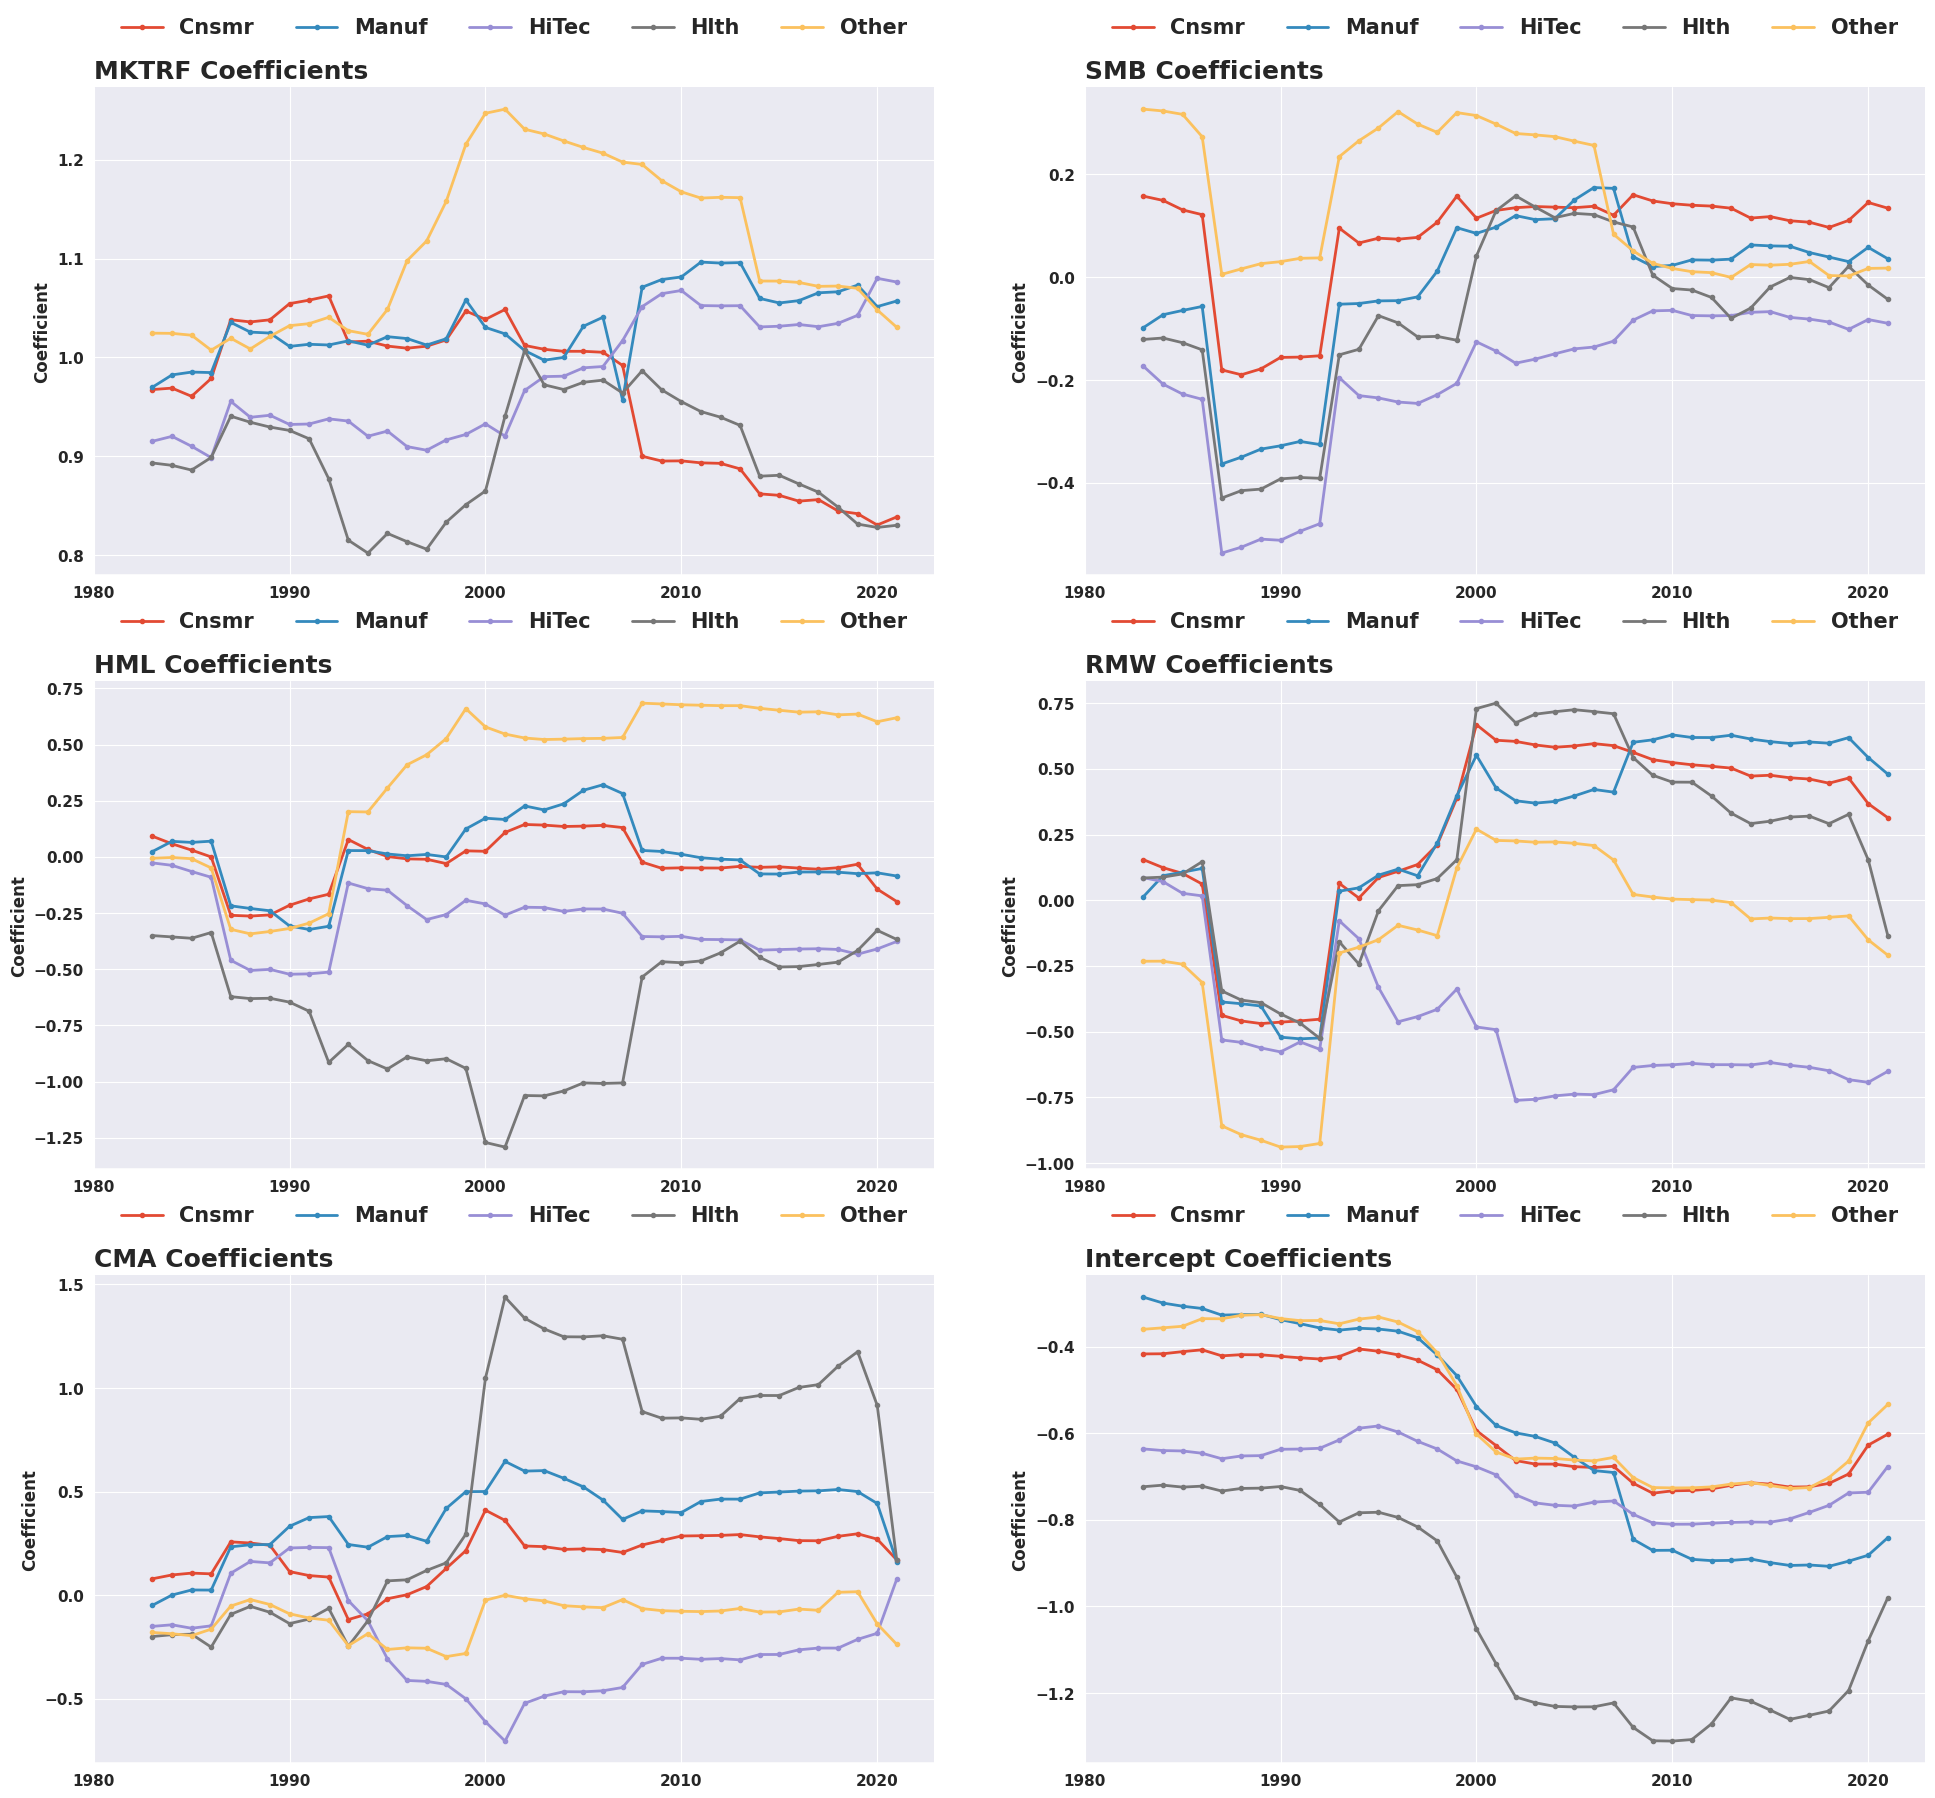

In [18]:
plot_rolling_coefficients_together(rolling_coefs)